In [79]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [80]:
import missingno as msno

missing_summary = pd.DataFrame({
    'Missing Values': train.isna().sum(),
    'Percentage': (train.isna().mean() * 100)
})

print(missing_summary)

              Missing Values  Percentage
PassengerId                0    0.000000
HomePlanet               201    2.312205
CryoSleep                217    2.496261
Cabin                    199    2.289198
Destination              182    2.093639
Age                      179    2.059128
VIP                      203    2.335212
RoomService              181    2.082135
FoodCourt                183    2.105142
ShoppingMall             208    2.392730
Spa                      183    2.105142
VRDeck                   188    2.162660
Name                     200    2.300702
Transported                0    0.000000


In [81]:
for col in train.columns:
    num_unique = train[col].nunique()

    if num_unique > 20:
        print(f"{col}: {num_unique} unique values")

    else:
        print(f"{col}, {num_unique}: {train[col].unique()}")

    print("-------")

PassengerId: 8693 unique values
-------
HomePlanet, 3: ['Europa' 'Earth' 'Mars' nan]
-------
CryoSleep, 2: [False True nan]
-------
Cabin: 6560 unique values
-------
Destination, 3: ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan]
-------
Age: 80 unique values
-------
VIP, 2: [False True nan]
-------
RoomService: 1273 unique values
-------
FoodCourt: 1507 unique values
-------
ShoppingMall: 1115 unique values
-------
Spa: 1327 unique values
-------
VRDeck: 1306 unique values
-------
Name: 8473 unique values
-------
Transported, 2: [False  True]
-------


<Figure size 1200x1000 with 0 Axes>

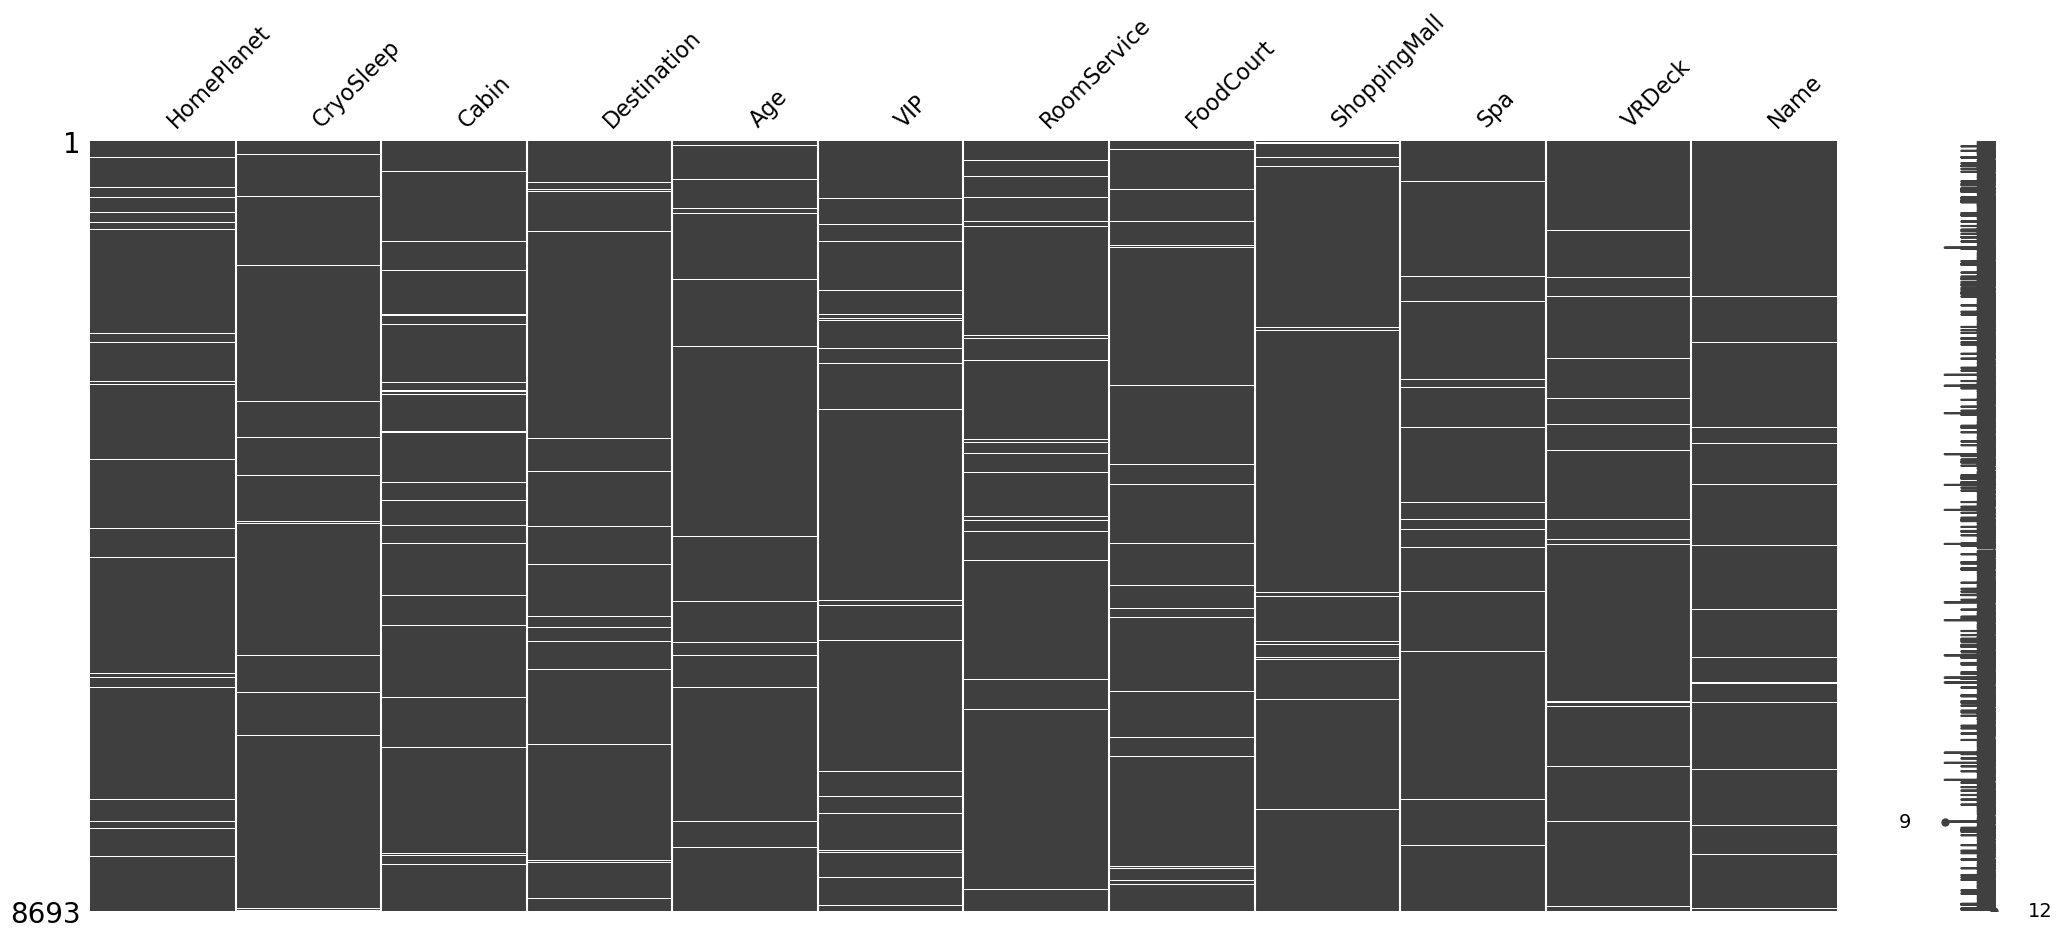

In [82]:
import matplotlib.pyplot as plt

cols_to_check = train.columns.drop(['PassengerId', 'Transported'])

plt.figure(figsize=(12, 10))
msno.matrix(train[cols_to_check])
plt.show()

<Axes: >

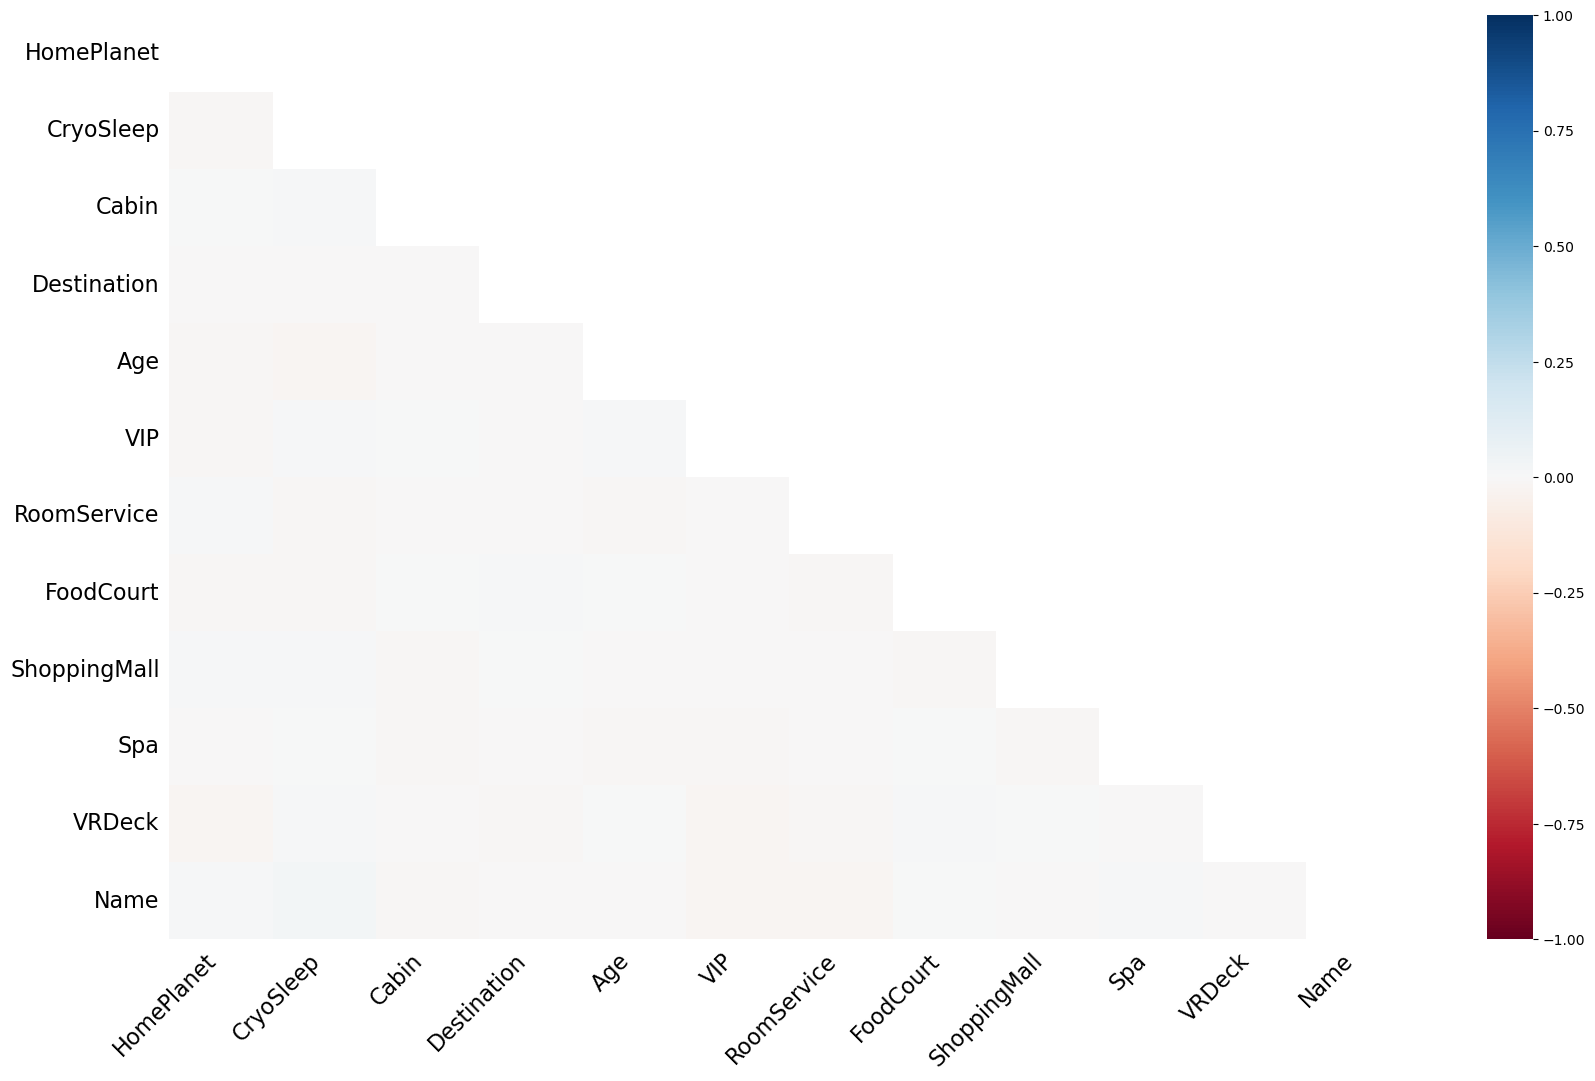

In [83]:
msno.heatmap(train[cols_to_check])

In [84]:
train[['Deck', 'Cabin_No','Side']] = train['Cabin'].str.split('/',expand=True)
train[['GroupID', 'MemberID']] = train['PassengerId'].str.split('_', expand=True)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
 14  Deck          8494 non-null   object 
 15  Cabin_No      8494 non-null   object 
 16  Side          8494 non-null   object 
 17  GroupID       8693 non-null   object 
 18  MemberID      8693 non-null 

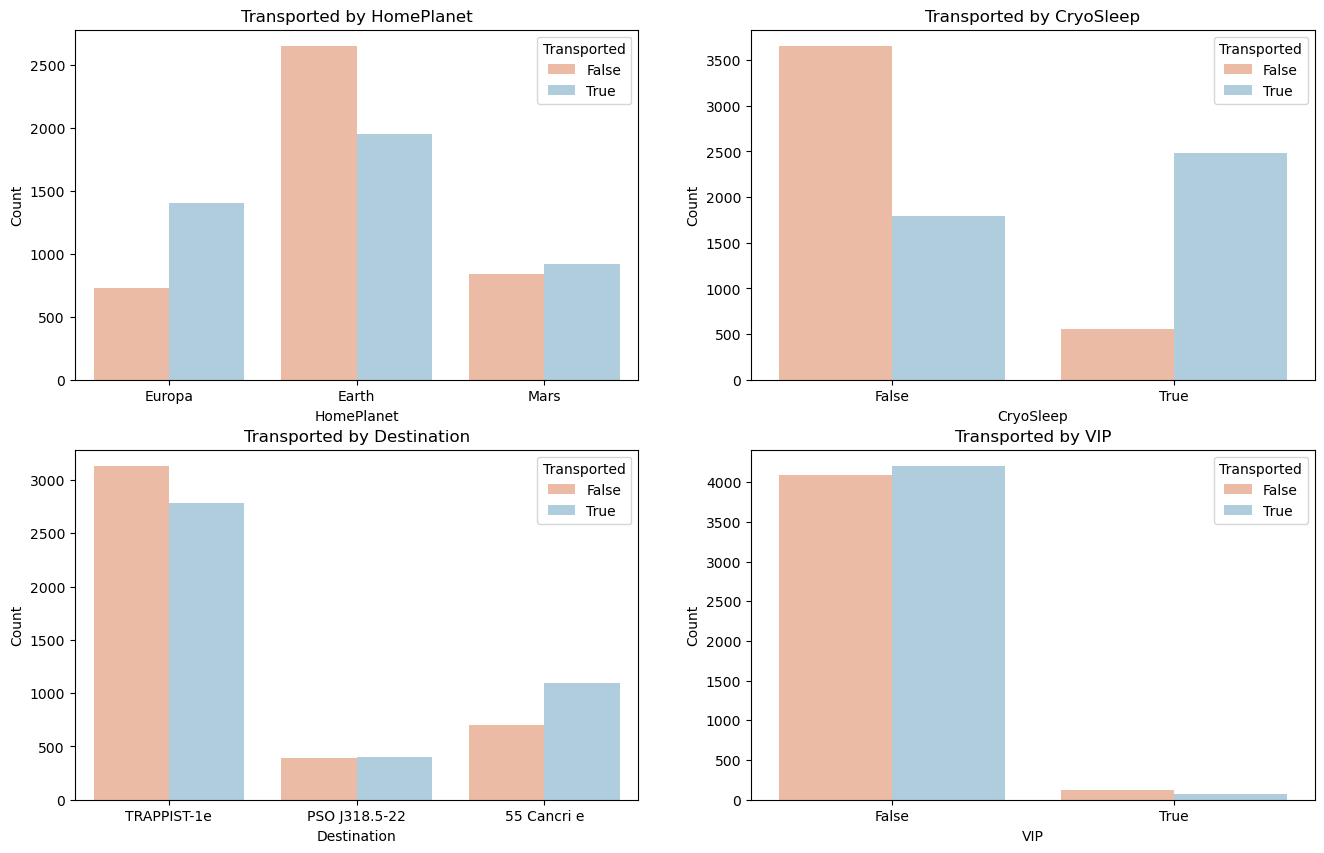

In [85]:
import seaborn as sns

cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2,2, figsize=(16, 10))

for i, col in enumerate(cat_cols):
    
    ax = axes[i // 2, i % 2]
    sns.countplot(data=train, x=col, hue='Transported', ax=ax, palette='RdBu')

    ax.set_title(f'Transported by {col}')
    ax.set_ylabel('Count')

plt.show()

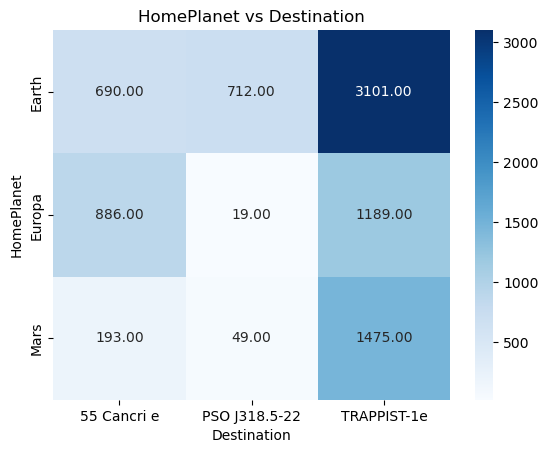

In [86]:
ct = pd.crosstab(train['HomePlanet'], train['Destination'])

plt.Figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt= '.2f', cmap='Blues')
plt.title('HomePlanet vs Destination')
plt.show()


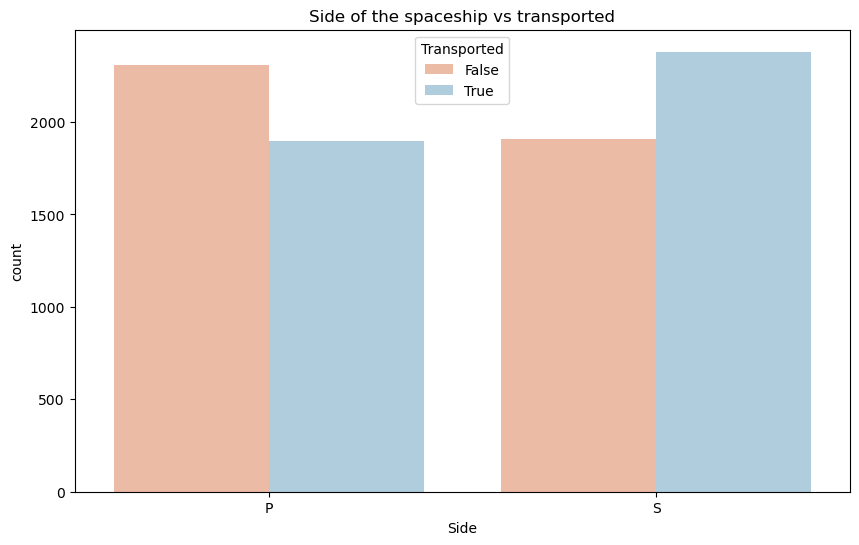

In [87]:
plt.figure(figsize=(10,6))
sns.countplot(data=train, x='Side', hue='Transported', palette='RdBu')
plt.title("Side of the spaceship vs transported")
plt.show()

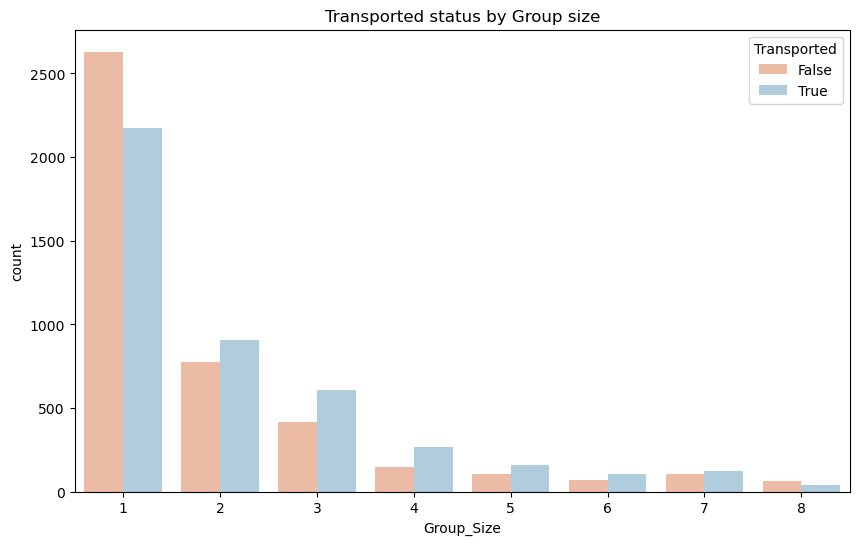

In [88]:
group_counts = train['GroupID'].value_counts()
train["Group_Size"] = train["GroupID"].map(group_counts)

plt.figure(figsize=(10,6))
sns.countplot(data=train, x='Group_Size', hue='Transported', palette='RdBu')
plt.title("Transported status by Group size")
plt.show()

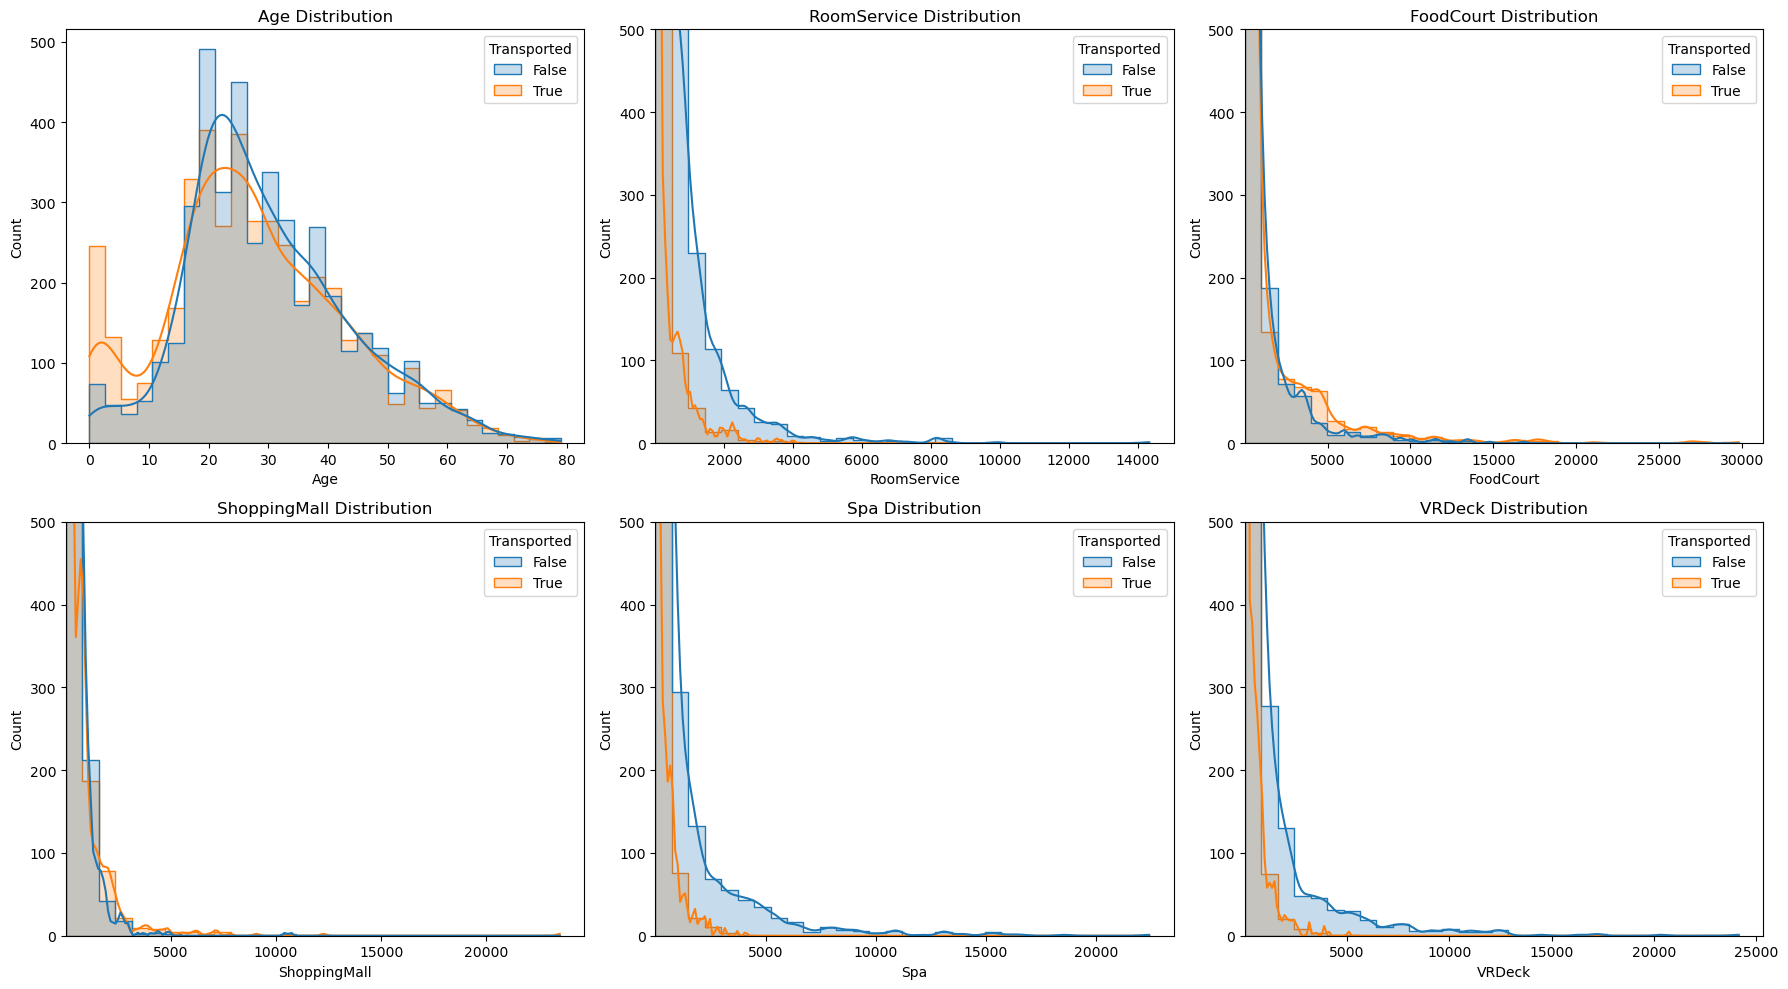

In [89]:
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', "VRDeck"]

fig, axes = plt.subplots(2,3, figsize = (18,10))

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=train, x=col, hue='Transported', kde=True, element='step', bins=30, ax=ax)

    ax.set_title(f'{col} Distribution')

    if col != 'Age':
        ax.set_ylim(0, 500)
        ax.set_xlim(0.5000)

plt.tight_layout()
plt.show()

C:\Users\baibh\AppData\Local\Temp\ipykernel_43380\2619884460.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Transported', y='Age', palette='coolwarm')


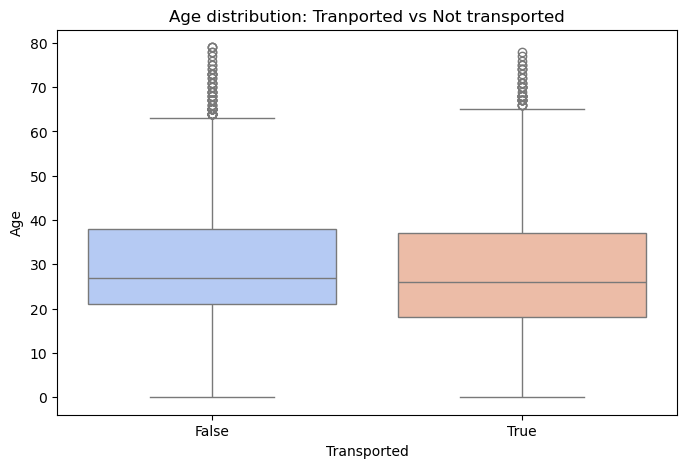

In [90]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='Transported', y='Age', palette='coolwarm')
plt.title("Age distribution: Tranported vs Not transported")
plt.show()

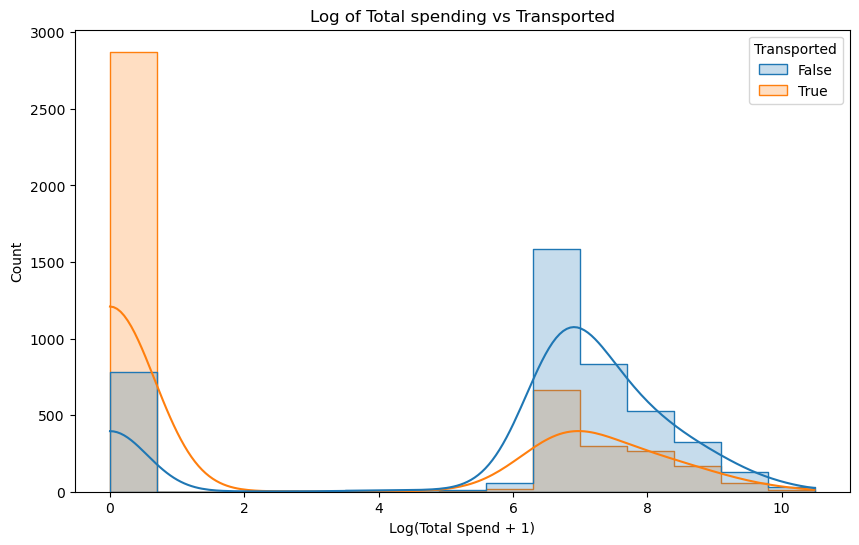

In [91]:
train['TotalSpend'] = (
                        train['RoomService'].fillna(0) +
                        train['FoodCourt'].fillna(0) +
                        train['ShoppingMall'].fillna(0) +
                        train['Spa'].fillna(0) +
                        train['VRDeck'].fillna(0))

import numpy as np
train['LogTotalSpend'] = np.log1p(train['TotalSpend'])

plt.figure(figsize=(10,6))
sns.histplot(data=train, x='LogTotalSpend', hue='Transported', kde=True, element='step')
plt.title("Log of Total spending vs Transported")
plt.xlabel("Log(Total Spend + 1)")
plt.show()

<Axes: >

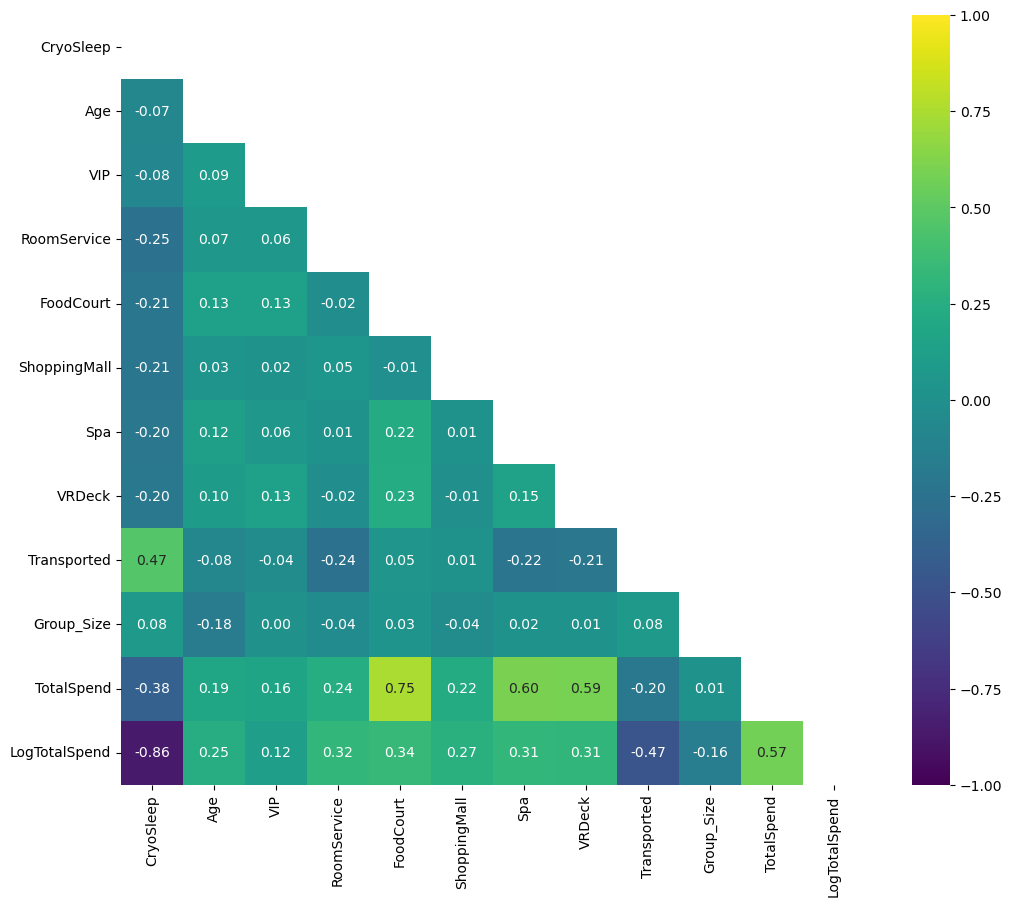

In [92]:
corr_df = train.copy()

for col in ['Transported', 'CryoSleep', 'VIP']:
    if col in corr_df.columns:
        corr_df[col] = corr_df[col].astype(float)

numerical_df = corr_df.select_dtypes(include=['number'])

corr_matrix = numerical_df.corr()

plt.figure(figsize=(12,10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='viridis', vmin=-1, vmax=1, center=0, mask=mask)